# 🎬 Movie Rating Prediction - Final Assignment Part 2
**Gil Hatiel & Liel Leone | Machine Learning Course**

## ⚙️ Imports & Setup

Loading all required libraries and defining global constants used throughout the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import os
import warnings
import shap
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    cross_validate, cross_val_predict,
    KFold, GridSearchCV, train_test_split
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import set_config
import joblib

# Style
plt.rcParams['figure.figsize']    = (12, 5)
plt.rcParams['font.size']         = 13
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.titlepad']     = 10

GREEN  = '#2ecc71'
RED    = '#e74c3c'
BLUE   = '#3498db'
ORANGE = '#f39c12'

set_config(display='diagram')

print('✅ All set!')

✅ All set!


---
## 🔍 Part 1 - Exploratory Data Analysis (EDA)

We begin by understanding the raw data before any processing.
The goal is to identify data quality issues, missing values, and potential features.


In [2]:
# ── 1.1  Load the data ───────────────────────────────────────────
df_raw = pd.read_csv('dataset.csv', low_memory=False)

In [3]:
# ── 1.2  First Look ──────────────────────────────────────────────
# shape
print(f'📦 Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

📦 Shape: 133,884 rows × 13 columns


In [4]:
# random sample of 5 rows
df_raw.sample(5, random_state=42)

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
3115,tt1507306,Jangan Pandang Belakang Congkak,2009.0,"Comedy,Fantasy,Horror","['nm0784094', 'nm3603389', 'nm3603159', 'nm360...",90.0,3.4,NaN,NaN,87.0,NaN,NaN,NaN
14399,tt7520068,Kolej Havasi,2019.0,Documentary,"['nm11454310', 'nm11454313', 'nm11454314', 'nm...",105.0,8.7,NaN,NaN,259.0,NaN,NaN,NaN
132162,tt7021508,Honey: Rise Up and Dance,2018.0,"Drama,Music","nm3692520, nm7005977, nm2057826, nm0496980, nm...",100.0,5.0,NaN,NaN,1013.0,NaN,NaN,NaN
94863,tt22898390,Anmitsu hime: Yôjutsu kurabe no maki,1954.0,NaN,"['nm0950825', 'nm0473530', 'nm1090569', 'nm178...",65.0,NaN,NaN,NaN,0.0,NaN,NaN,"Anmitsu Hime ( あんみつ姫 ; ""Princess Anmitsu "") is..."
27537,tt0466456,Midsummer Madness,2007.0,"[""Comedy"", ""Drama"", ""Romance""]","[""nm0684500"", ""nm0920366"", ""nm1616309"", ""nm060...",94.0,5.9,Latvian,Latvia,625.0,3.5,NaN,NaN


In [5]:
# data types per column
df_raw.dtypes

tconst              object
primaryTitle        object
startYear          float64
genres              object
lead_actors_ids     object
runtimeMinutes     float64
averageRating      float64
Language            object
Country             object
numVotes           float64
budget              object
BoxOffice          float64
plot                object
dtype: object

In [6]:
# descriptive statistics — numerical columns only
df_raw.describe().round(2)

,startYear,runtimeMinutes,averageRating,numVotes,BoxOffice
count,133884.00,133884.00,115560.00,124762.00,1.791600e+04
mean,1995.64,97.24,6.07,7562.01,4.705076e+07
std,64.75,22.92,1.29,54834.44,2.894113e+09
min,0.00,60.00,1.00,0.00,0.000000e+00
25%,1982.00,84.00,5.30,36.00,1.000000e+00
50%,2007.00,93.00,6.20,173.00,7.900000e+00
75%,2017.00,106.00,7.00,879.00,6.095000e+01
max,2026.00,300.00,10.00,3186698.00,3.120000e+11


In [7]:
# duplicate rows
print('Duplicate rows:  ', df_raw.duplicated().sum())
print('Duplicate tconst:', df_raw['tconst'].duplicated().sum())

Duplicate rows:   0
Duplicate tconst: 0


In [8]:
# ── 1.3  Missing Values ──────────────────────────────────────────
missing = pd.DataFrame({
    'missing_count': df_raw.isnull().sum(),
    'missing_%':     (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
}).sort_values('missing_%', ascending=False)

display(missing)

,missing_count,missing_%
budget,117334,87.6
BoxOffice,115968,86.6
Country,80203,59.9
Language,78162,58.4
plot,74215,55.4
averageRating,18324,13.7
lead_actors_ids,10030,7.5
numVotes,9122,6.8
genres,2573,1.9
tconst,0,0.0


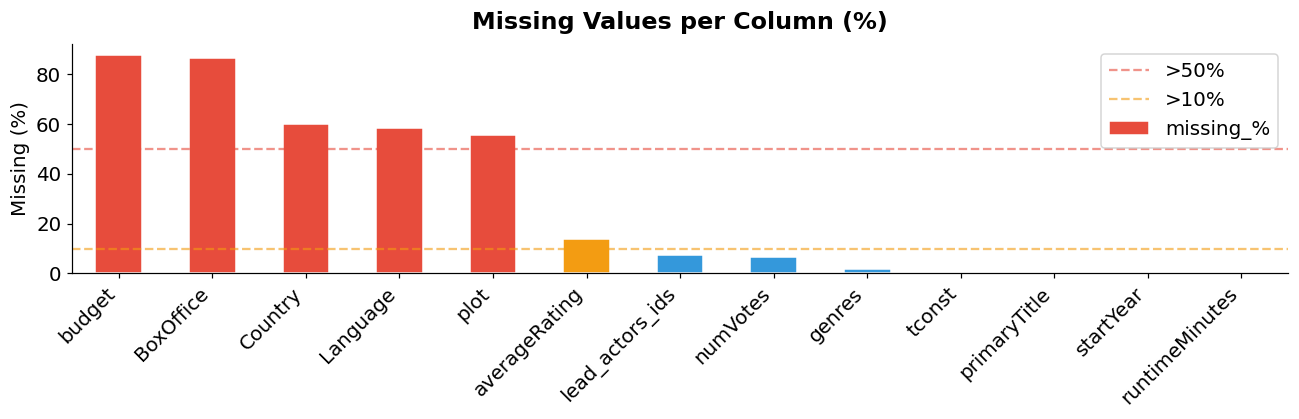

In [9]:
# bar chart — red > 50%, orange > 10%, blue otherwise
fig, ax = plt.subplots(figsize=(12, 4))
colors = [RED if p > 50 else ORANGE if p > 10 else BLUE
          for p in missing['missing_%']]
missing['missing_%'].plot(kind='bar', ax=ax, 
                          color=colors, edgecolor='white')
ax.set_title('Missing Values per Column (%)', fontweight='bold')
ax.set_ylabel('Missing (%)')
ax.axhline(50, color=RED,    linestyle='--', alpha=0.6, label='>50%')
ax.axhline(10, color=ORANGE, linestyle='--', alpha=0.6, label='>10%')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

`budget` and `BoxOffice` are missing in over 80% of rows.
`Country`, `Language`, and `plot` are also partially missing.
`numVotes` and `BoxOffice` will be removed in `prepare_data` as they cause data leakage.
For the remaining columns, missingness will be handled inside the Pipeline.

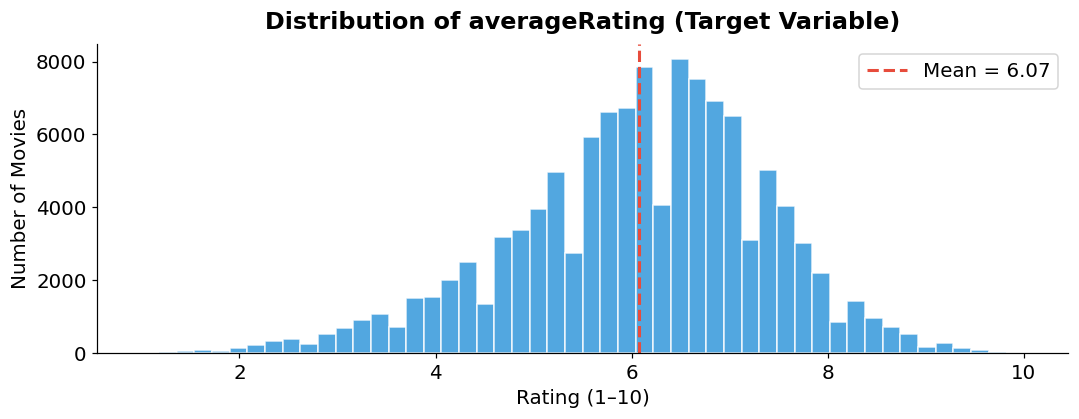

In [10]:
# ── 1.4  Target Variable — averageRating ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_raw['averageRating'].dropna(), bins=50,
        color=BLUE, edgecolor='white', alpha=0.85)
ax.axvline(df_raw['averageRating'].mean(), color=RED,
           linestyle='--', linewidth=2,
           label=f'Mean = {df_raw["averageRating"].mean():.2f}')
ax.set_title('Distribution of averageRating (Target Variable)', 
             fontweight='bold')
ax.set_xlabel('Rating (1–10)')
ax.set_ylabel('Number of Movies')
ax.legend()
plt.tight_layout()
plt.show()

The distribution is approximately bell-shaped, centered around a mean of 6.07.
Most movies are rated between 5 and 8. Both tails (below 3 and above 9) are sparse -
the model will struggle more with extreme ratings due to limited training examples.

In [11]:
# ── 1.5  Data Quality Checks ─────────────────────────────────────
# suspicious startYear values — films before 1888 predate cinema
df_raw[df_raw['startYear'] < 1888]

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
64465,tt10209920,Alien Wars: Judgement Day,0.0,['Sci-Fi'],"['nm3782241', 'nm0357405', 'nm0245223', 'nm177...",90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64533,tt3580466,Alhambra Decree 1492,0.0,"['Adventure', 'Drama', 'History']","['nm0537631', 'nm0001934', 'nm2454994', 'nm106...",110.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64627,tt4764536,Action Not Words,0.0,['Action'],"['nm0584473', 'nm4106347', 'nm2335825', 'nm914...",91.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64687,tt3116542,Alam High School,0.0,"['Documentary', 'History']",['nm0013037'],150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64828,tt7727364,All That Ends,0.0,['Drama'],['nm9164025'],90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71658,tt14998708,Agent Surya,0.0,"['Crime', 'Mystery', 'Thriller']",['nm8242827'],120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71761,tt41141748,All That's Left,0.0,"['Drama', 'Sci-Fi']","['nm7956133', 'nm6672073', 'nm15672591', 'nm09...",85.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71816,tt1662622,Aleya's Tango: Dreams of a Vampyre,0.0,"['Drama', 'Fantasy', 'Musical']","['nm3935935', 'nm3223702', 'nm3927793', 'nm392...",82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71855,tt35681860,Almost Blue,0.0,"['Crime', 'Drama']","['nm17002694', 'nm17002692', 'nm17002697', 'nm...",88.0,NaN,Italian,Italy,NaN,NaN,NaN,NaN


In [12]:
# ── 1.6  Genres ──────────────────────────────────────────────────
# sample — checking raw format first
df_raw['genres'].dropna().sample(10, random_state=42)

99501                           Horror
52515                       ['Comedy']
123260                          Comedy
56892                           Comedy
10238                           Comedy
22659     ["Comedy", "Crime", "Drama"]
31858             ['Drama', 'Romance']
92674                           Comedy
32120                        ['Drama']
129685                   Comedy,Horror
Name: genres, dtype: object

In [13]:
# all unique genres in the dataset — after splitting multi-genre entries
genres_split = df_raw['genres'].dropna().str.replace(r"[\[\]'\"]", '', regex=True)
genres_split = genres_split.str.split(',').explode().str.strip()
print(f'Unique genres: {genres_split.nunique()}')
display(genres_split.value_counts().to_frame('count'))

Unique genres: 30


,count
genres,
Drama,64056
Comedy,35201
Documentary,18264
Romance,16584
Action,14862
Crime,13017
Thriller,12296
Horror,10371
Adventure,8657


Two formats detected: `"Comedy,Horror"` and `['Drama', 'Romance']`.
Empty entries (`[]`) and `\N` values will be cleaned inside `prepare_data`.
Missing values will be handled inside the Pipeline.

In [14]:
# ── 1.7  Country ─────────────────────────────────────────────────
# sample — checking raw format
df_raw['Country'].dropna().sample(20, random_state=42)

75971                United States
48319                 Soviet Union
119901                   Not Found
22195                United States
24169                       Sweden
89825                United States
122771                       India
59948                   Azerbaijan
43544     United States of America
112694               United States
117104               United States
50198             Hong Kong, China
94336                  Philippines
41969               United Kingdom
36977                       Canada
83028               United Kingdom
48003                       Brazil
72512                  South Korea
24526                      Denmark
69485                      Ecuador
Name: Country, dtype: object

In [15]:
# entries with multiple countries — co-productions
multi = df_raw['Country'].str.contains(r'[,/]', na=False, regex=True)
print(f'Multi-country entries: {multi.sum():,} ({multi.sum()/df_raw["Country"].notna().sum()*100:.1f}% of non-null)')
print()
# sample of multi-country entries
df_raw[multi][['primaryTitle', 'Country']].sample(5, random_state=42)

Multi-country entries: 2,052 (3.8% of non-null)



,primaryTitle,Country
64105,The Black Dahlia,"France, Germany, United States"
20321,Little Monsters,"['Australia', 'United States', 'United Kingdom']"
108751,Cause toujours!,"France, Italy"
108725,Cured,"France, United Kingdom, Ireland, United States"
81684,White Fang,"Italy, , Spain, , France"


3.8% of movies list more than one country due to international co-productions.
The primary (first) country will be used for the `country_group` feature.
In addition, a binary `is_coproduction` feature will be created inside `prepare_data`.

In [16]:
# ── 1.8  Actors ──────────────────────────────────────────────────
# sample — checking raw format
df_raw['lead_actors_ids'].dropna().sample(5, random_state=42)

82437     ['nm0680983', 'nm0644897', 'nm0013037', 'nm185...
83108     ['nm0846070', 'nm0814033', 'nm0434223', 'nm071...
50652     ['nm0058181', 'nm0087142', 'nm0160945', 'nm019...
80415     ['nm4404734', 'nm0911854', 'nm4178142', 'nm523...
121940    nm1156207, nm4539846, nm2636694, nm4540117, nm...
Name: lead_actors_ids, dtype: object

In [17]:
# number of actors per movie
n_act = df_raw['lead_actors_ids'].apply(
    lambda x: len(re.findall(r'nm\d+', str(x))) if pd.notna(x) else np.nan
)
n_act.value_counts(dropna=False).sort_index()

lead_actors_ids
0.0     8873
1.0     3934
2.0     3599
3.0     5302
4.0     5832
5.0    96314
NaN    10030
Name: count, dtype: int64

Two formats detected: list format `['nm001', 'nm002']` and plain string `nm001, nm002`.
Regex (`nm\d+`) correctly extracts actor IDs from both formats.

In [18]:
# ── 1.9  Language ─────────────────────────────────────────────────
# sample — checking raw format
df_raw['Language'].dropna().sample(10, random_state=42)

106316      English
43118       English
50455     Malayalam
47123       English
26106       English
27403         Greek
20590       English
119415      Italian
43885         Malay
118095    Not Found
Name: Language, dtype: object

In [19]:
# movies containing English (including multi-language entries)
has_english = df_raw['Language'].str.contains('english', case=False, na=False).sum()
print(f'Movies with English: {has_english:,} ({has_english/len(df_raw)*100:.1f}%)')

Movies with English: 29,432 (22.0%)


In [20]:
# movies with more than one language
multi_lang = df_raw['Language'].str.contains(r'[,/]|\s+\w+', na=False, regex=True)
print(f'Multi-language entries: {multi_lang.sum():,} ({multi_lang.sum()/df_raw["Language"].notna().sum()*100:.1f}% of non-null)')

# sample
df_raw[multi_lang][['primaryTitle', 'Language']].sample(5, random_state=42)

Multi-language entries: 6,177 (11.1% of non-null)


,primaryTitle,Language
73655,Troll Hunter,Norwegian English
77664,Ulysses,Italian English
108614,"Crystal or Ash, Fire or Wind, as Long as It's ...","English, Italian"
20905,La Vie En Rose,"['French', 'English']"
112182,Crazy About Paris,"French, English, Italian, Spanish, Portuguese ..."


The Language column contains multiple formats: single language, comma-separated,
space-separated, and list format `['French', 'English']`.
These inconsistencies are handled inside `prepare_data` using case-insensitive
substring matching.

## Part 2 - Feature Engineering Motivation

Before building `prepare_data`, we examined which features are worth engineering
and validated their data coverage. Features were selected based on external knowledge
and domain reasoning - not based on rating data from our dataset.

#### Directors & Actors
Before adding director and actor recognition as features, we first validate
whether there is sufficient data support for this decision.

We compiled a list of 15 internationally acclaimed directors and 10 acclaimed actors
based on external criteria only: Academy Award wins/nominations for Best Director,
major festival awards (Cannes, Venice, Berlin), and broad historical recognition
in world cinema — without using any rating data or IMDb rankings from our dataset.
Further details are provided in the AI usage log in the report.

IMDb crew files were used only to verify name coverage in our dataset
not to select or rank the directors or actors.

Here we check how many movies in our dataset feature one of these directors or actors,
to ensure there is enough coverage to justify adding these as features.

Note: no columns are added to `df_raw` here - features are created inside `prepare_data`.

In [21]:
# ── EDA only — not required for model training ───────────────────
# ── 2.1  Directors & Actors ──────────────────────────────────────
try:
    crew = pd.read_csv('title.crew.tsv', sep='\t', na_values='\\N',
                       usecols=['tconst', 'directors'])
    crew = crew[crew['tconst'].isin(df_raw['tconst'])]
    
    # collect director nconsts
    all_nconsts = set()
    for directors in crew['directors'].dropna():
        for nid in directors.split(','):
            all_nconsts.add(nid.strip())
    
    # add actor nconsts from df_raw
    for ids in df_raw['lead_actors_ids'].dropna():
        for nid in re.findall(r'nm\d+', str(ids)):
            all_nconsts.add(nid.strip())
    
    # read names — keep only relevant
    names_list = []
    for chunk in pd.read_csv('name.basics.tsv', sep='\t', na_values='\\N',
                              usecols=['nconst', 'primaryName'],
                              chunksize=500_000):
        names_list.append(chunk[chunk['nconst'].isin(all_nconsts)])
    names = pd.concat(names_list, ignore_index=True)
    print(f"crew: {len(crew):,} | names: {len(names):,}")
except Exception as e:
    print(f"Skipping EDA cell: {e}")
    crew = names = None

crew: 133,881 | names: 307,657


In [22]:
# map director name to each movie
if crew is not None and names is not None:
    crew['director_id'] = crew['directors'].str.split(',').str[0]
    crew_merged = crew.merge(names, left_on='director_id', right_on='nconst', how='left')
    dir_map = dict(zip(crew_merged['tconst'], crew_merged['primaryName']))

    n_with_director = df_raw['tconst'].map(dir_map).notna().sum()
    print(f'Movies with identified director: {n_with_director:,} ({n_with_director/len(df_raw)*100:.1f}%)')
else:
    print("Skipping — crew/names not loaded")

Movies with identified director: 132,617 (99.1%)


In [23]:
# how many movies have multiple directors?
multi_dir = crew['directors'].dropna()
multi = multi_dir.str.contains(',', na=False).sum()
total = multi_dir.notna().sum()
print(f'Movies with multiple directors: {multi:,} ({multi/total*100:.1f}% of non-null)')
print()
# sample
print('Sample:')
display(crew[crew['directors'].str.contains(',', na=False)].sample(5))

Movies with multiple directors: 11,871 (9.0% of non-null)

Sample:


,tconst,directors,director_id
11314018,tt7274816,"nm2104585,nm9214848",nm2104585
5742374,tt22489564,"nm3871075,nm12926016",nm3871075
4713992,tt1805374,"nm2485323,nm0551655",nm2485323
799534,tt0826026,"nm2323957,nm2314971",nm2323957
4837041,tt1855226,"nm0485344,nm1635066",nm0485344


In [24]:
# ── checking all directors vs first only ─────────────────────────
if crew is not None and names is not None:
    ACCLAIMED_DIRECTORS = [
        'Billy Wilder', 'Francis Ford Coppola',
        'Alfred Hitchcock', 'Akira Kurosawa',
        'Federico Fellini', 'Ingmar Bergman', 'Hayao Miyazaki', 'Orson Welles',
        'Pedro Almodovar', 'Wong Kar Wai', 'Stanley Kubrick',
        'Steven Spielberg', 'Martin Scorsese',
        'Christopher Nolan', 'Quentin Tarantino', 'Bong Joon Ho', 'Ridley Scott',
        'David Fincher', 'Denis Villeneuve', 'Clint Eastwood'
    ]

    _crew_lookup  = dict(zip(crew['tconst'],  crew['directors']))
    nconst_to_name = dict(zip(names['nconst'], names['primaryName']))

    # first director only
    first_only = df_raw['tconst'].apply(
        lambda t: int(dir_map.get(t, '') in ACCLAIMED_DIRECTORS)
    )

    # all directors
    all_dirs = df_raw['tconst'].apply(
        lambda t: int(any(
            nconst_to_name.get(nid.strip(), '') in ACCLAIMED_DIRECTORS
            for nid in str(_crew_lookup.get(t, '')).split(',')
            if nid.strip()
        )) if pd.notna(t) else 0
    )

    print(f'First director only: {first_only.sum():,}')
    print(f'All directors:       {all_dirs.sum():,}')
    print(f'Additional movies:   {all_dirs.sum() - first_only.sum():,}')
else:
    print("Skipping — crew/names not loaded")

First director only: 322
All directors:       341
Additional movies:   19


In [25]:
# ── acclaimed actors coverage check ──────────────────────────────
if names is not None:
    ACCLAIMED_ACTORS = [
        'Marlon Brando', 'Humphrey Bogart',
        'Audrey Hepburn', 'Katharine Hepburn',
        'Sophia Loren', 'Dustin Hoffman',
        'Jack Nicholson', 'Meryl Streep',
        'Daniel Day-Lewis', 'Anthony Hopkins',
        'Cate Blanchett', 'Tom Hanks',
        'Al Pacino', 'Robert De Niro',
        'Amitabh Bachchan', 'Leonardo DiCaprio',
        'Joaquin Phoenix', 'Denzel Washington',
        'Chadwick Boseman', 'Natalie Portman'
    ]
    acclaimed_ids_new = set(names[names['primaryName'].isin(ACCLAIMED_ACTORS)]['nconst'])
    for actor in ACCLAIMED_ACTORS:
        actor_ids = set(names[names['primaryName'] == actor]['nconst'])
        n = df_raw['lead_actors_ids'].apply(
            lambda x: any(nm in actor_ids for nm in re.findall(r'nm\d+', str(x)))
        ).sum()
        print(f'{actor:25s}: {n:4d} movies')
    total = df_raw['lead_actors_ids'].apply(
        lambda x: any(nm in acclaimed_ids_new for nm in re.findall(r'nm\d+', str(x)))
    ).sum()
    print(f'\nTotal: {total:,}')
else:
    print("Skipping — names not loaded")

Marlon Brando            :   25 movies
Humphrey Bogart          :   50 movies
Audrey Hepburn           :   12 movies
Katharine Hepburn        :   21 movies
Sophia Loren             :   25 movies
Dustin Hoffman           :   39 movies
Jack Nicholson           :   36 movies
Meryl Streep             :   32 movies
Daniel Day-Lewis         :   16 movies
Anthony Hopkins          :   45 movies
Cate Blanchett           :   31 movies
Tom Hanks                :   43 movies
Al Pacino                :   35 movies
Robert De Niro           :   74 movies
Amitabh Bachchan         :  105 movies
Leonardo DiCaprio        :   25 movies
Joaquin Phoenix          :   30 movies
Denzel Washington        :   34 movies
Chadwick Boseman         :    5 movies
Natalie Portman          :   25 movies

Total: 677


In [26]:
# ── check for multiple IDs per actor ─────────────────────────────
print("=== IDs per actor ===")
for actor in ACCLAIMED_ACTORS:
    actor_ids = names[names['primaryName'] == actor]['nconst'].tolist()
    print(f'{actor:25s}: {actor_ids}')

=== IDs per actor ===
Marlon Brando            : ['nm0000008']
Humphrey Bogart          : ['nm0000007']
Audrey Hepburn           : ['nm0000030']
Katharine Hepburn        : ['nm0000031']
Sophia Loren             : ['nm0000047']
Dustin Hoffman           : ['nm0000163']
Jack Nicholson           : ['nm0000197']
Meryl Streep             : ['nm0000658']
Daniel Day-Lewis         : ['nm0000358']
Anthony Hopkins          : ['nm0000164']
Cate Blanchett           : ['nm0000949']
Tom Hanks                : ['nm0000158']
Al Pacino                : ['nm0000199']
Robert De Niro           : ['nm0000134']
Amitabh Bachchan         : ['nm0000821']
Leonardo DiCaprio        : ['nm0000138']
Joaquin Phoenix          : ['nm0001618']
Denzel Washington        : ['nm0000243']
Chadwick Boseman         : ['nm1569276']
Natalie Portman          : ['nm0000204']


Each actor appears under a single IMDb ID in our dataset.
We use the existing `lead_actors_ids` column directly to match against
a pre-compiled set of acclaimed actor IDs without any additional joins.

In [27]:
# ── free EDA memory before model training ────────────────────────
to_delete = ['crew_merged', 'dir_map', '_crew_lookup', 
             'nconst_to_name', 'multi_dir', 'crew', 
             'names', 'chunk', 'names_list']
for var in to_delete:
    try:
        del globals()[var]
    except KeyError:
        pass
import gc
gc.collect()
print("Memory cleared")

Memory cleared


#### Countries

We selected 10 countries based on their global presence in the film industry,
using external knowledge (AI tool) — not based on our dataset.
Movies from countries outside this list will be grouped under `Other_Country`.

In [28]:
# ── 2.2  Countries — coverage check ──────────────────────────────
SELECTED_COUNTRIES = [
    'United States', 'India', 'United Kingdom', 'France',
    'Japan', 'China', 'Germany', 'South Korea',
    'Italy', 'Canada'
]

for country in SELECTED_COUNTRIES:
    n   = df_raw['Country'].str.contains(country, na=False).sum()
    pct = n / len(df_raw) * 100
    print(f'{country:20s}: {n:6,} ({pct:.1f}%)')

United States       : 21,703 (16.2%)
India               :  7,244 (5.4%)
United Kingdom      :  3,823 (2.9%)
France              :  2,948 (2.2%)
Japan               :  1,693 (1.3%)
China               :    510 (0.4%)
Germany             :  1,818 (1.4%)
South Korea         :    787 (0.6%)
Italy               :  2,347 (1.8%)
Canada              :  1,643 (1.2%)


#### Genres

We selected 15 genres based on global recognition in the film industry,
using external knowledge (AI tool) — not based on our dataset.

In [29]:
# ── 2.3  Genres — coverage check ─────────────────────────────────
SELECTED_GENRES = [
    'Drama', 'Comedy', 'Thriller', 'Action', 'Romance',
    'Horror', 'Crime', 'Documentary', 'Adventure', 'Animation',
    'Fantasy', 'Biography', 'Mystery', 'Sci-Fi', 'Family'
]

for genre in SELECTED_GENRES:
    n   = df_raw['genres'].str.contains(genre, na=False).sum()
    pct = n / len(df_raw) * 100
    print(f'{genre:15s}: {n:6,} ({pct:.1f}%)')

Drama          : 64,056 (47.8%)
Comedy         : 35,201 (26.3%)
Thriller       : 12,296 (9.2%)
Action         : 14,862 (11.1%)
Romance        : 16,584 (12.4%)
Horror         : 10,371 (7.7%)
Crime          : 13,017 (9.7%)
Documentary    : 18,264 (13.6%)
Adventure      :  8,657 (6.5%)
Animation      :  2,612 (2.0%)
Fantasy        :  4,414 (3.3%)
Biography      :  4,641 (3.5%)
Mystery        :  5,874 (4.4%)
Sci-Fi         :  3,522 (2.6%)
Family         :  5,332 (4.0%)


## 🧹 Part 3 - `prepare_data` Function

The function receives the raw DataFrame and returns a processed DataFrame
with engineered features ready for the model.
A full feature table is provided in the report.

Key decisions: no imputation inside the function — missing values handled
by the Pipeline. Leakage columns (`numVotes`, `BoxOffice`) removed at the start.

In [30]:
def prepare_data(df):
    import os
    df = df.copy()

    # ---------------------------------------------------------------
    # remove leakage columns
    # ---------------------------------------------------------------
    if 'averageRating' in df.columns:
        df = df.dropna(subset=['averageRating'])
    leakage_cols = ['numVotes', 'BoxOffice']
    df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

    # ---------------------------------------------------------------
    # release year — NaN remains, Pipeline fills median from fold
    # ---------------------------------------------------------------
    df['startYear'] = pd.to_numeric(df['startYear'], errors='coerce')
    df.loc[df['startYear'] < 1888, 'startYear'] = np.nan
    df['decade'] = (df['startYear'] // 10 * 10)

    # ---------------------------------------------------------------
    # runtime — binning
    # ---------------------------------------------------------------
    df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')
    def categorize_runtime(val):
        if pd.isna(val) or val == 0: return 'no_data'
        elif val <= 80:              return 'short'
        elif val <= 120:             return 'medium'
        else:                        return 'long'
    df['runtime_cat'] = df['runtimeMinutes'].apply(categorize_runtime)

    # ---------------------------------------------------------------
    # genres — selected based on global recognition in world cinema
    # ---------------------------------------------------------------
    SELECTED_GENRES = [
        'Drama', 'Comedy', 'Thriller', 'Action', 'Romance',
        'Horror', 'Crime', 'Documentary', 'Adventure', 'Animation',
        'Fantasy', 'Biography', 'Mystery', 'Sci-Fi', 'Family'
    ]
    def normalize_genres(val):
        if pd.isna(val) or str(val).strip() == '\\N': return ''
        val = re.sub(r"[\[\]'\"]", '', str(val))
        genres = [g.strip().title() for g in val.split(',') if g.strip()]
        return ','.join(sorted(genres))

    df['genres']   = df['genres'].apply(normalize_genres)
    df['n_genres'] = df['genres'].apply(lambda x: len(x.split(',')) if x else 0)
    for genre in SELECTED_GENRES:
        col = f'genre_{genre.lower().replace("-","_").replace(" ","_")}'
        df[col] = df['genres'].apply(
            lambda x, g=genre: int(g in x.split(',')) if x else 0
        )


    # ---------------------------------------------------------------
    # country — normalization only, encoding happens in Pipeline
    # ---------------------------------------------------------------
    COUNTRY_ALIASES = {
        'Usa': 'United States', 'Us': 'United States',
        'U.S.': 'United States', 'U.S.A.': 'United States',
        'United States Of America': 'United States',
        'Uk': 'United Kingdom', 'Great Britain': 'United Kingdom',
        'England': 'United Kingdom',
        'Ussr': 'Russia', 'Soviet Union': 'Russia',
        'West Germany': 'Germany', 'East Germany': 'Germany',
        'Not Found': 'Unknown',
    }
    def extract_primary_country(val):
        if pd.isna(val): return 'Unknown'
        val = re.sub(r'\[\d+\]', '', str(val))
        val = re.sub(r"[\[\]'\"]", '', val)
        parts = re.split(r'[,/]', val)
        country = parts[0].strip().title()
        if not country: return 'Unknown'
        return COUNTRY_ALIASES.get(country, country)

    df['country_clean']   = df['Country'].apply(extract_primary_country)

    # ---------------------------------------------------------------
    # budget
    # ---------------------------------------------------------------
    budget_clean = pd.to_numeric(
        df['budget'].str.replace(r'[$,]', '', regex=True), errors='coerce'
    )
    df['budget_reported'] = budget_clean.notna().astype(int)

    # ---------------------------------------------------------------
    # language
    # ---------------------------------------------------------------
    df['is_english'] = df['Language'].str.contains(
        'English', case=False, na=False
    ).astype(int)

    # ---------------------------------------------------------------
    # plot
    # ---------------------------------------------------------------
    EMPTY_PLOT_PATTERNS = r'(?i)(no plot|not available|n/a|none|plot unknown|no synopsis|not found|^\s*$)'
    df['plot_length'] = df['plot'].apply(
        lambda x: len(str(x).split())
        if pd.notna(x) and not re.match(EMPTY_PLOT_PATTERNS, str(x).strip())
        else 0
    )

    # ---------------------------------------------------------------
    # directors — selected based on Oscar wins, major festival awards,
    # and broad historical recognition in world cinema
    # ---------------------------------------------------------------
    ACCLAIMED_DIRECTORS = [
        'William Wyler',        'Billy Wilder',
        'Francis Ford Coppola', 'Steven Spielberg',
        'Martin Scorsese',      'Alfred Hitchcock',
        'Akira Kurosawa',       'Federico Fellini',
        'Ingmar Bergman',       'Hayao Miyazaki',
        'Orson Welles',         'Pedro Almodovar',
        'Wong Kar Wai',         'Stanley Kubrick',
        'Christopher Nolan',    'Quentin Tarantino',
        'Bong Joon Ho',         'Ridley Scott',
        'David Fincher',        'Clint Eastwood'
    ]

    if 'director' in df.columns:
        df['director_acclaimed'] = df['director'].isin(ACCLAIMED_DIRECTORS).astype(int)
        df['n_directors']        = 1

    elif 'tconst' in df.columns:
        _crew  = None
        _names = None
        if os.path.exists('title.crew.tsv') and os.path.exists('name.basics.tsv'):
            _crew  = pd.read_csv('title.crew.tsv',  sep='\t', na_values='\\N',
                                 usecols=['tconst', 'directors'])
            _names = pd.read_csv('name.basics.tsv', sep='\t', na_values='\\N',
                                 usecols=['nconst', 'primaryName'])

        if _crew is not None and _names is not None:
            _crew_lookup    = dict(zip(_crew['tconst'],  _crew['directors']))
            _nconst_to_name = dict(zip(_names['nconst'], _names['primaryName']))

            # n_directors — number of directors per movie
            df['n_directors'] = df['tconst'].apply(
                lambda t: len([x for x in str(_crew_lookup.get(t, '')).split(',')
                               if x.strip()])
                if pd.notna(t) else 0
            )

            # director_acclaimed — checks all directors per movie
            df['director_acclaimed'] = df['tconst'].apply(
                lambda t: int(any(
                    _nconst_to_name.get(nid.strip(), '') in ACCLAIMED_DIRECTORS
                    for nid in str(_crew_lookup.get(t, '')).split(',')
                    if nid.strip()
                )) if pd.notna(t) else 0
            )
        else:
            df['director_acclaimed'] = 0
            df['n_directors']        = 0
    else:
        df['director_acclaimed'] = 0
        df['n_directors']        = 0

    # ---------------------------------------------------------------
    # actors — selected based on Oscar wins, AFI recognition,
    # and broad international recognition
    # ---------------------------------------------------------------
    ACCLAIMED_ACTOR_IDS = {
        'nm0000008', 'nm0000007', 'nm0000030', 'nm0000031', 'nm0000047',
        'nm0000163', 'nm0000197', 'nm0000658', 'nm0000358', 'nm0000164',
        'nm0000949', 'nm0000158', 'nm0000199', 'nm0000134', 'nm0000821',
        'nm0000138', 'nm0001618', 'nm0000243', 'nm1569276', 'nm0000204',
    }

    if 'lead_actors_ids' in df.columns:
        df['has_actors']      = df['lead_actors_ids'].notna().astype(int)
        df['actor_acclaimed'] = df['lead_actors_ids'].apply(
            lambda x: int(any(nm in ACCLAIMED_ACTOR_IDS
                             for nm in re.findall(r'nm\d+', str(x))))
        )
    else:
        df['has_actors']      = 0
        df['actor_acclaimed'] = 0

    # ---------------------------------------------------------------
    # drop raw columns
    # ---------------------------------------------------------------
    drop_cols = ['tconst', 'primaryTitle', 'lead_actors_ids',
                 'Language', 'budget', 'plot', 'director',
                 'runtimeMinutes', 'genres', 'Country', 'startYear']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # ---------------------------------------------------------------
    # drop averageRating — target variable, not a feature
    # ---------------------------------------------------------------
    if 'averageRating' in df.columns:
        df = df.drop(columns=['averageRating'])

    return df

In [31]:
# ── verify prepare_data on full dataset ──────────────────────
df_processed = prepare_data(df_raw)
print(f'Shape: {df_processed.shape}')
print(f'Columns ({len(df_processed.columns)}): {df_processed.columns.tolist()}')

Shape: (115560, 26)
Columns (26): ['decade', 'runtime_cat', 'n_genres', 'genre_drama', 'genre_comedy', 'genre_thriller', 'genre_action', 'genre_romance', 'genre_horror', 'genre_crime', 'genre_documentary', 'genre_adventure', 'genre_animation', 'genre_fantasy', 'genre_biography', 'genre_mystery', 'genre_sci_fi', 'genre_family', 'country_clean', 'budget_reported', 'is_english', 'plot_length', 'n_directors', 'director_acclaimed', 'has_actors', 'actor_acclaimed']


## Part 4 - Model Building

We build two models: ElasticNet (required) and Random Forest.
Both use the same Pipeline - all preprocessing (scaling, encoding, imputation)
happens inside the Pipeline on training folds only, preventing data leakage.

In [32]:
# ── prepare data ─────────────────────────────────────────────────
# prepare_data returns X only — averageRating is extracted separately
df_prepared = prepare_data(df_raw)
X = df_prepared
y = df_raw.loc[df_prepared.index, 'averageRating']


In [33]:
# ── train / test split ───────────────────────────────────────────
# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
numerical_vars = ['decade', 'n_genres', 'plot_length', 'n_directors']
categorical_vars = ['runtime_cat', 'country_clean']

genre_vars = [
    f'genre_{g.lower().replace("-","_").replace(" ","_")}'
    for g in [
        'Drama', 'Comedy', 'Thriller', 'Action', 'Romance',
        'Horror', 'Crime', 'Documentary', 'Adventure', 'Animation',
        'Fantasy', 'Biography', 'Mystery', 'Sci-Fi', 'Family'
    ]
]

binary_vars = [
    'budget_reported', 'is_english',
    'director_acclaimed',
    'actor_acclaimed', 'has_actors',
] + genre_vars

pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('OHE',     OneHotEncoder(max_categories=15,
                              sparse_output=False,
                              handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num',    pipe_num,      numerical_vars),
    ('cat',    pipe_cat,      categorical_vars),
    ('binary', 'passthrough', binary_vars)
])

In [35]:
# ── ElasticNet pipeline ───────────────────────────────────────────
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        ElasticNet(max_iter=10000, random_state=42))
])

In [36]:
# pipeline diagram
display(pipeline)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [38]:
# ── step 1 — ElasticNet: find optimal parameters ─────────────────
param_grid_en = {
    'model__alpha':    [0.0001,0.001, 0.01, 0.1, 1.0],
    'model__l1_ratio': [0.1, 0.2, 0.5]
}

gs_en = GridSearchCV(
    pipeline, param_grid_en,
    cv=10,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
gs_en.fit(X_train, y_train)

print("ElasticNet — best params:", gs_en.best_params_)

Fitting 10 folds for each of 15 candidates, totalling 150 fits
ElasticNet — best params: {'model__alpha': 0.0001, 'model__l1_ratio': 0.1}


In [39]:
# ── step 2 — ElasticNet: official 10-fold CV results ─────────────
cv_en = cross_validate(
    gs_en.best_estimator_,
    X, y,
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'r2':   'r2'
    }
)

print("ElasticNet — 10-Fold CV Results:")
print(f"  RMSE: {-cv_en['test_rmse'].mean():.4f} ± {cv_en['test_rmse'].std():.4f}")
print(f"  MAE:  {-cv_en['test_mae'].mean():.4f}  ± {cv_en['test_mae'].std():.4f}")
print(f"  R²:   {cv_en['test_r2'].mean():.4f}  ± {cv_en['test_r2'].std():.4f}")

ElasticNet — 10-Fold CV Results:
  RMSE: 1.1317 ± 0.0100
  MAE:  0.8665  ± 0.0069
  R²:   0.2336  ± 0.0072


In [40]:
# ── Random Forest pipeline ────────────────────────────────────────
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        RandomForestRegressor(random_state=42))
])

In [41]:
# pipeline diagram
display(pipeline_rf)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [42]:
# ── step 3 — Random Forest: find optimal parameters ──────────────
param_grid_rf = {
    'model__n_estimators':      [200, 300],
    'model__max_depth':         [10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
}

gs_rf = GridSearchCV(
    pipeline_rf, param_grid_rf,
    cv=10,
    scoring='neg_root_mean_squared_error',
    n_jobs=2,
    verbose=1
)
gs_rf.fit(X_train, y_train)

print("Random Forest — best params:", gs_rf.best_params_)
print(f"RMSE (GridSearch CV): {-gs_rf.best_score_:.4f}")

Fitting 10 folds for each of 18 candidates, totalling 180 fits
Random Forest — best params: {'model__max_depth': 20, 'model__min_samples_split': 10, 'model__n_estimators': 300}
RMSE (GridSearch CV): 1.1163


In [46]:
# ── step 4 — Random Forest: official 10-fold CV results ──────────
cv_rf = cross_validate(
    gs_rf.best_estimator_,
    X, y,
    cv=KFold(n_splits=10, shuffle=True, random_state=42),
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'r2':   'r2'
    }
)

print("Random Forest — 10-Fold CV Results:")
print(f"  RMSE: {-cv_rf['test_rmse'].mean():.4f} ± {cv_rf['test_rmse'].std():.4f}")
print(f"  MAE:  {-cv_rf['test_mae'].mean():.4f}  ± {cv_rf['test_mae'].std():.4f}")
print(f"  R²:   {cv_rf['test_r2'].mean():.4f}  ± {cv_rf['test_r2'].std():.4f}")

Random Forest — 10-Fold CV Results:
  RMSE: 1.1129 ± 0.0094
  MAE:  0.8463  ± 0.0073
  R²:   0.2588  ± 0.0064


In [47]:
# ── step 5 — out-of-fold predictions ─────────────────────────────
# using cross_val_predict to get one prediction per movie
# without data leakage — each movie predicted by a model
# that never saw it during training
KF = KFold(n_splits=10, shuffle=True, random_state=42)

y_pred_rf = cross_val_predict(
    gs_rf.best_estimator_,
    X=X, y=y, cv=KF, n_jobs=2
)
y_pred_en = cross_val_predict(
    gs_en.best_estimator_,
    X=X, y=y, cv=KF, n_jobs=2
)

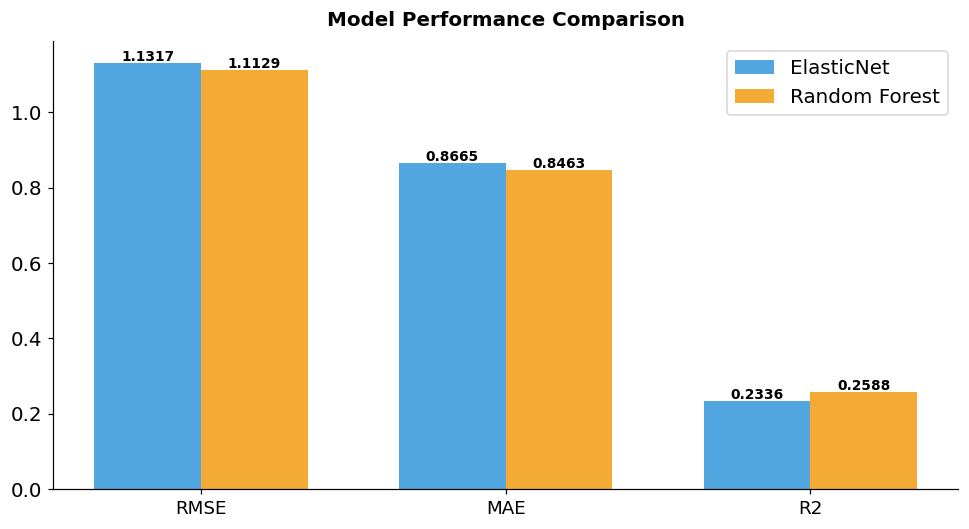

In [49]:
# ── model performance comparison — visual ───────────────────
results = pd.DataFrame({
    'Model': ['ElasticNet', 'Random Forest'],
    'RMSE':  [-cv_en['test_rmse'].mean(), -cv_rf['test_rmse'].mean()],
    'MAE':   [-cv_en['test_mae'].mean(),  -cv_rf['test_mae'].mean()],
    'R2':    [cv_en['test_r2'].mean(),     cv_rf['test_r2'].mean()]
}).round(4).set_index('Model')

metrics = results.columns.tolist()
en_vals = results.loc['ElasticNet'].tolist()
rf_vals = results.loc['Random Forest'].tolist()

x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, en_vals, w, label='ElasticNet',    color= BLUE, alpha=0.85)
ax.bar(x + w/2, rf_vals, w, label='Random Forest', color=ORANGE, alpha=0.85)

for i, (e, r) in enumerate(zip(en_vals, rf_vals)):
    ax.text(i - w/2, e + 0.005, f'{e:.4f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(i + w/2, r + 0.005, f'{r:.4f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## Part 5 — Error Analysis

In this section we examine the cases where the Random Forest model made the
largest prediction errors. We use the out-of-fold predictions computed in
Part 4 (`y_pred_rf`) - ensuring no movie was predicted by a model it was
trained on.

We analyze:
- The 10 largest **overpredictions** — model predicted much higher than actual rating
- The 10 largest **underpredictions** — model predicted much lower than actual rating

For each group we identify common patterns and discuss potential improvements.

In [50]:
# ── 5.1  build error dataframe ───────────────────────────────────
errors_df = pd.DataFrame({
    'title':  df_raw.loc[X.index, 'primaryTitle'],
    'y_true': y.values,
    'y_pred': y_pred_rf,
    'error':  y_pred_rf - y.values
}, index=X.index)

errors_df['abs_error'] = errors_df['error'].abs()

In [51]:
# ── 5.2  top 10 over & underpredictions ──────────────────────────
over  = errors_df.nlargest(10,  'error')[['title', 'y_true', 'y_pred', 'error']].round(2).reset_index(drop=True)
under = errors_df.nsmallest(10, 'error')[['title', 'y_true', 'y_pred', 'error']].round(2).reset_index(drop=True)

display(over.style.set_caption('Top 10 Overpredictions'))
display(under.style.set_caption('Top 10 Underpredictions'))

,title,y_true,y_pred,error
0,Ramo Trip,1.400000,7.740000,6.340000
1,Horseplay: The History of Horse Riding,1.000000,7.220000,6.220000
2,Justin Bieber: Always Believing,1.000000,7.220000,6.220000
3,Rape of the Soul,1.700000,7.820000,6.120000
4,Kurz,1.200000,7.180000,5.980000
5,Play in the Gray,1.300000,7.130000,5.830000
6,Kids Against the Sorcerers,1.100000,6.900000,5.800000
7,Justin Bieber's Believe,1.600000,7.400000,5.800000
8,Tribalism Is Killing Us,1.300000,7.060000,5.760000
9,Brush with Life: The Art of Being Edward Biberman,1.500000,7.190000,5.690000


,title,y_true,y_pred,error
0,Justicia Implacable,9.500000,4.110000,-5.390000
1,Pulse of the Indigo,9.300000,4.280000,-5.020000
2,Bukunja Tekunja Mitti: The Cannibals,9.100000,4.120000,-4.980000
3,Halloween Deluxe,9.100000,4.280000,-4.820000
4,Akkada Varu Ikkada Unnaru,9.100000,4.350000,-4.750000
5,Il Santo Veleno,9.400000,4.660000,-4.740000
6,Son-nim-1 Cheo-beon-jjae I-ya-gi,9.100000,4.410000,-4.690000
7,Alya,8.700000,4.020000,-4.680000
8,Hell Squad 2: Fresh Meat,8.900000,4.260000,-4.640000
9,Avengers: Doom of the World,8.900000,4.310000,-4.590000


The results confirm the pattern from Section 1.4: the model struggles most
with extreme ratings at both tails of the distribution.

**Overpredictions:** movies with actual ratings of 1.0–1.7 were predicted ~7.
The model has few training examples of truly bad movies and defaults to the center.

**Underpredictions:** movies with actual ratings of 8.7–9.6 were predicted ~4–5.
These are niche films with dedicated community audiences — a dynamic the model
cannot detect from structural features alone.

In [52]:
# ── 5.3  feature inspection — 5 specific movies ──────────────────
target_movies = [
    'Justin Bieber: Always Believing',      # over
    'Tribalism Is Killing Us',              # over
    'Justicia Implacable',                  # under
    'Bukunja Tekunja Mitti: The Cannibals', # under
    'Son-nim-1 Cheo-beon-jjae I-ya-gi'     # under
]

inspection = errors_df[errors_df['title'].isin(target_movies)].copy()
inspection = inspection.merge(
    X.loc[inspection.index],
    left_index=True, right_index=True
)

cols_to_show = [
    'title', 'y_true', 'y_pred', 'error',
    'decade', 'runtime_cat', 'n_genres',
] + genre_vars + [
    'country_clean', 'is_english',
    'plot_length',
    'budget_reported',
    'director_acclaimed', 'n_directors',
    'actor_acclaimed', 'has_actors',
]

pd.set_option('display.max_columns', None)
inspection = inspection.sort_values(by='error', ascending=False)

display(inspection[cols_to_show].round(2))


,title,y_true,y_pred,error,decade,runtime_cat,n_genres,genre_drama,genre_comedy,genre_thriller,genre_action,genre_romance,genre_horror,genre_crime,genre_documentary,genre_adventure,genre_animation,genre_fantasy,genre_biography,genre_mystery,genre_sci_fi,genre_family,country_clean,is_english,plot_length,budget_reported,director_acclaimed,n_directors,actor_acclaimed,has_actors
12464,Justin Bieber: Always Believing,1.0,7.22,6.22,2010.0,short,2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,Unknown,0,0,0,0,1,0,1
72010,Tribalism Is Killing Us,1.3,7.06,5.76,2010.0,medium,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,Unknown,0,23,0,0,1,0,0
57344,Son-nim-1 Cheo-beon-jjae I-ya-gi,9.1,4.41,-4.69,2010.0,medium,2,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,Unknown,0,0,0,0,1,0,1
106898,Bukunja Tekunja Mitti: The Cannibals,9.1,4.12,-4.98,2010.0,short,2,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,Unknown,0,0,0,0,1,0,1
9295,Justicia Implacable,9.5,4.11,-5.39,2020.0,medium,3,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,Unknown,0,0,0,0,1,0,1


In [53]:
# ── 5.4  feature table for all 20 outliers ───────────────────────
all_outliers = pd.concat([
    over.assign(group='Over'),
    under.assign(group='Under')
], ignore_index=True)

outlier_rows = errors_df[errors_df['title'].isin(all_outliers['title'])].copy()

outlier_features = outlier_rows.merge(
    X.loc[outlier_rows.index], left_index=True, right_index=True
).merge(all_outliers[['title', 'group']], on='title')

analysis_cols = [
    'title', 'group', 'y_true', 'y_pred', 'error',
    'decade', 'runtime_cat', 'n_genres',
    'country_clean', 'is_english', 'budget_reported', 'plot_length',
    'genre_documentary', 'genre_horror', 'genre_drama', 'genre_biography',
    'director_acclaimed', 'n_directors', 'actor_acclaimed', 'has_actors'
]

# show 2 examples from each group
sample = outlier_features.groupby('group')[analysis_cols].apply(
    lambda g: g.sample(2, random_state=42)
).reset_index(drop=True)
display(sample.round(2))

,title,group,y_true,y_pred,error,decade,runtime_cat,n_genres,country_clean,is_english,budget_reported,plot_length,genre_documentary,genre_horror,genre_drama,genre_biography,director_acclaimed,n_directors,actor_acclaimed,has_actors
0,Brush with Life: The Art of Being Edward Biberman,Over,1.5,7.19,5.69,2000.0,medium,1,Unknown,0,0,0,1,0,0,0,0,1,0,1
1,Justin Bieber: Always Believing,Over,1.0,7.22,6.22,2010.0,short,2,Unknown,0,0,0,1,0,0,0,0,1,0,1
2,Hell Squad 2: Fresh Meat,Under,8.9,4.26,-4.64,2020.0,medium,1,Unknown,0,0,0,0,1,0,0,0,2,0,1
3,Justicia Implacable,Under,9.5,4.11,-5.39,2020.0,medium,3,Unknown,0,0,0,0,1,1,0,0,1,0,1


In [54]:
# ── 5.5  deeper exploration of outlier characteristics ───────────

explore_cols = ['group', 'y_true', 'y_pred', 'error',
                'decade', 'n_genres',
                'is_english', 'budget_reported',
                'plot_length', 'n_directors', 'has_actors']

explore_cols = [c for c in explore_cols if c in outlier_features.columns]

display(outlier_features[explore_cols].groupby('group').mean().round(2)\
        .style.set_caption('Mean feature values by group'))

,y_true,y_pred,error,decade,n_genres,is_english,budget_reported,plot_length,n_directors,has_actors
group,,,,,,,,,,
Over,1.310000,7.280000,5.970000,2009.000000,1.800000,0.100000,0.100000,5.900000,1.300000,0.600000
Under,9.110000,4.280000,-4.830000,2016.000000,1.700000,0.100000,0.000000,11.100000,1.200000,0.900000


In [55]:
# ── 5.5  mean feature comparison: Over vs Under ───────────────────
numeric_features = [
    'is_english', 'budget_reported', 'plot_length', 'n_genres',
    'director_acclaimed', 'n_directors', 'actor_acclaimed', 'has_actors'
] + [c for c in X.columns if c.startswith('genre_')]

numeric_features = [c for c in numeric_features if c in outlier_features.columns]

comparison = outlier_features.groupby('group')[numeric_features].mean().T.round(3)
comparison['diff'] = (comparison['Over'] - comparison['Under']).round(3)
comparison = comparison.sort_values('diff', key=abs, ascending=False)

display(comparison)

group,Over,Under,diff
plot_length,5.9,11.1,-5.2
genre_documentary,0.9,0.0,0.9
genre_horror,0.0,0.6,-0.6
genre_action,0.0,0.4,-0.4
has_actors,0.6,0.9,-0.3
genre_thriller,0.0,0.3,-0.3
genre_animation,0.2,0.0,0.2
n_genres,1.8,1.7,0.1
genre_sci_fi,0.0,0.1,-0.1
n_directors,1.3,1.2,0.1


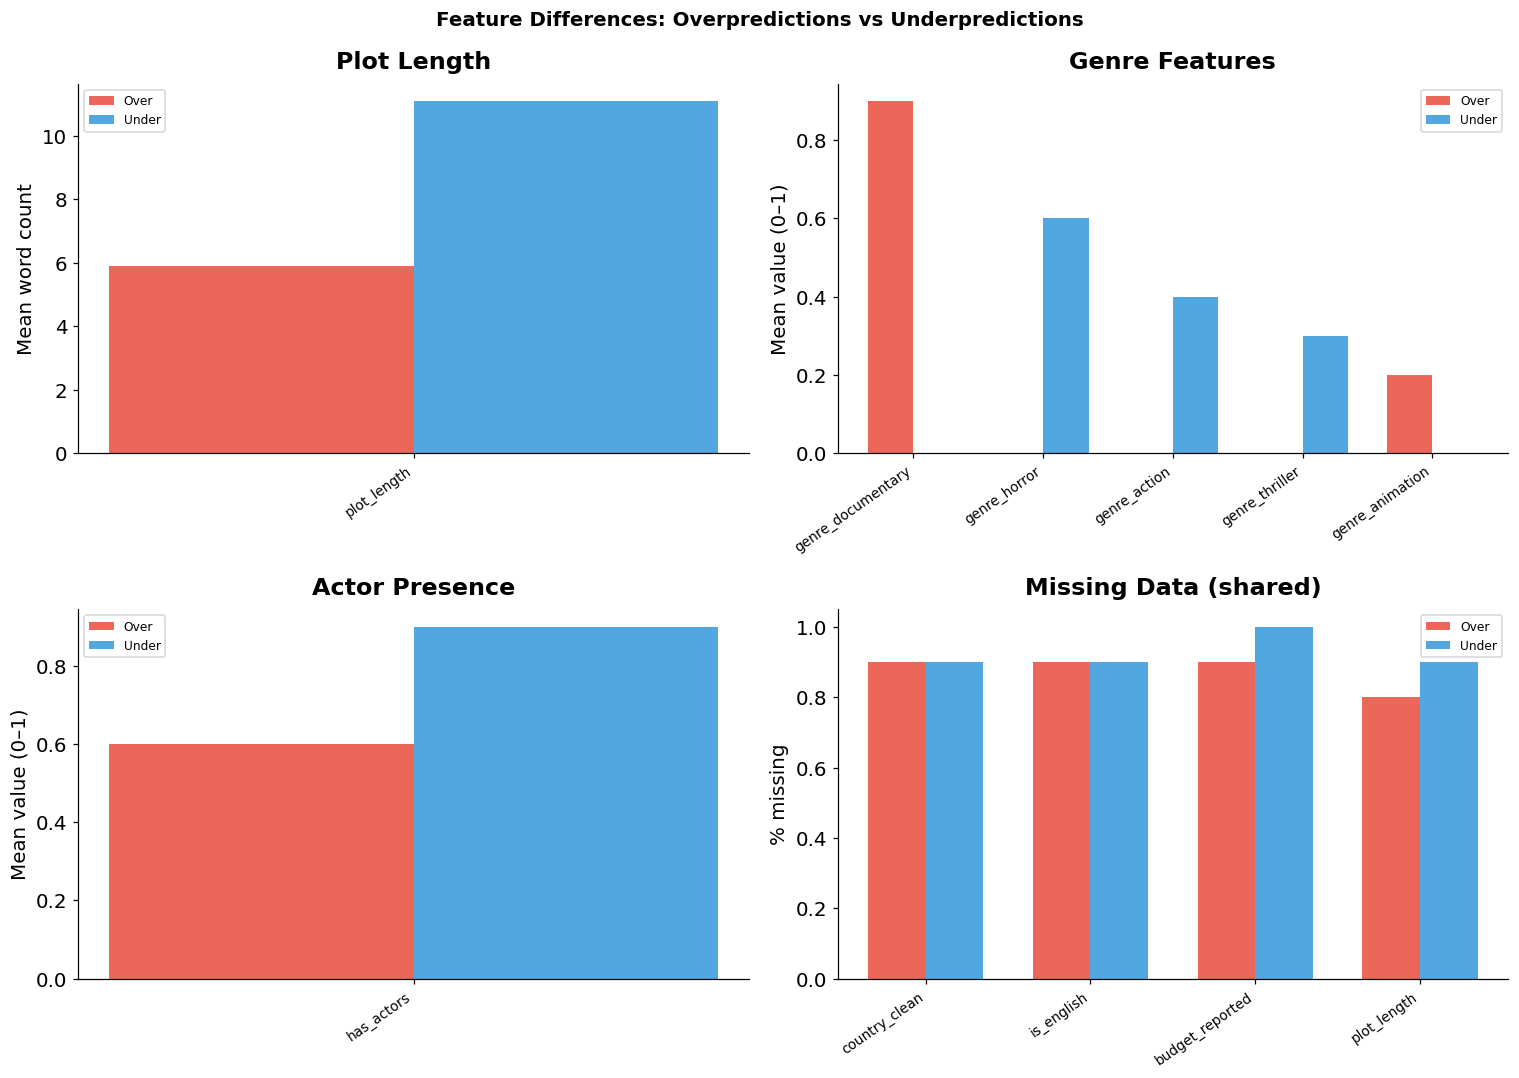

In [56]:
# ── 5.6  visual comparison: what separates Over from Under ────────

top_feats = comparison[comparison['diff'].abs() > 0.1].index.tolist()
binary_feats = [f for f in top_feats if f not in ('plot_length', 'has_actors')]

missing_checks = {'country_clean': 'Unknown', 'is_english': 0, 'budget_reported': 0, 'plot_length': 0}
missing_pct = pd.DataFrame({
    grp: [(outlier_features[outlier_features['group']==grp][f] == v).mean()
          for f, v in missing_checks.items()]
    for grp in ['Over', 'Under']
}, index=list(missing_checks.keys()))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
w = 0.35

configs = [
    (axes[0,0], ['plot_length'],  'Plot Length',          'Mean word count'),
    (axes[0,1], binary_feats,     'Genre Features',       'Mean value (0–1)'),
    (axes[1,0], ['has_actors'],   'Actor Presence',       'Mean value (0–1)'),
    (axes[1,1], list(missing_checks.keys()), 'Missing Data (shared)', '% missing'),
]

for ax, feats, title, ylabel in configs:
    x = np.arange(len(feats))
    data = missing_pct if title == 'Missing Data (shared)' else comparison
    ax.bar(x - w/2, data.loc[feats, 'Over'],  w, label='Over',  color=RED,  alpha=0.85)
    ax.bar(x + w/2, data.loc[feats, 'Under'], w, label='Under', color=BLUE, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(feats, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Feature Differences: Overpredictions vs Underpredictions',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

- **`genre_documentary`:** nearly all overpredicted films are documentaries
(Over=0.9, Under=0.0) — the model's strongest coefficient (+1.24)
systematically inflates predictions for this genre, regardless of actual rating.

- **`genre_horror / action / thriller`:** underpredicted films cluster in
these genres (Over=0.0, Under=0.3–0.6) - the model applies a blanket penalty,
yet several films achieved ratings of 8.7–9.6.

- **`plot_length`:** underpredicted films have more plot text on average
(11.1 vs 5.9 words), yet the model still failed - suggesting that plot length
alone does not capture the information needed to predict high ratings.

- **`has_actors`:** all underpredicted films have identified actors vs. only
60% of overpredicted films - insufficient to correct the error.

- **Missing data:** both groups exhibit near-identical missingness (~90%
unknown country, language, and budget). This confirms that missing data
contributes to prediction error in both cases, but does not explain the
directional difference between them.

In [57]:
# ── 5.7  build error dataframes for both models ───────────────────

errors_en = pd.DataFrame({
    'title': df_raw.loc[X.index, 'primaryTitle'],
    'y_true': y.values,
    'y_pred': y_pred_en,
    'error':  y_pred_en - y.values
}, index=X.index)

over_en  = set(errors_en.nlargest(10,  'error').index)
under_en = set(errors_en.nsmallest(10, 'error').index)
over_rf  = set(errors_df.nlargest(10,  'error').index)
under_rf = set(errors_df.nsmallest(10, 'error').index)

In [58]:
# ── 5.3  overlap between models ───────────────────────────────────
overlap_over  = list(over_en  & over_rf)
overlap_under = list(under_en & under_rf)

print(f"Overprediction overlap:  {len(overlap_over)}/10")
print(f"Underprediction overlap: {len(overlap_under)}/10")

shared_over = pd.DataFrame({
    'title':    errors_df.loc[overlap_over,  'title'],
    'y_true':   errors_df.loc[overlap_over,  'y_true'],
    'error_rf': errors_df.loc[overlap_over,  'error'],
    'error_en': errors_en.loc[overlap_over,  'error'],
}).round(2)
shared_over['better_model'] = shared_over.apply(
    lambda r: 'RF' if abs(r['error_rf']) < abs(r['error_en']) else 'EN', axis=1
)

shared_under = pd.DataFrame({
    'title':    errors_df.loc[overlap_under, 'title'],
    'y_true':   errors_df.loc[overlap_under, 'y_true'],
    'error_rf': errors_df.loc[overlap_under, 'error'],
    'error_en': errors_en.loc[overlap_under, 'error'],
}).round(2)
shared_under['better_model'] = shared_under.apply(
    lambda r: 'RF' if abs(r['error_rf']) < abs(r['error_en']) else 'EN', axis=1
)

display(shared_over.sort_values('error_rf', ascending=False)\
        .style.set_caption('Shared Overpredictions (both models)'))
display(shared_under.sort_values('error_rf', ascending=True)\
        .style.set_caption('Shared Underpredictions (both models)'))

Overprediction overlap:  6/10
Underprediction overlap: 4/10


,title,y_true,error_rf,error_en,better_model
12464,Justin Bieber: Always Believing,1.000000,6.220000,5.960000,EN
133563,Horseplay: The History of Horse Riding,1.000000,6.220000,6.500000,RF
52582,Rape of the Soul,1.700000,6.120000,5.960000,EN
16815,Kurz,1.200000,5.980000,5.920000,EN
45946,Play in the Gray,1.300000,5.830000,5.920000,RF
72010,Tribalism Is Killing Us,1.300000,5.760000,5.870000,RF


,title,y_true,error_rf,error_en,better_model
9295,Justicia Implacable,9.500000,-5.390000,-4.660000,EN
106898,Bukunja Tekunja Mitti: The Cannibals,9.100000,-4.980000,-4.710000,EN
69809,Akkada Varu Ikkada Unnaru,9.100000,-4.750000,-4.290000,EN
57344,Son-nim-1 Cheo-beon-jjae I-ya-gi,9.100000,-4.690000,-4.430000,EN


**Model Comparison: Overlap in Outliers**

Both models share 6/10 overpredictions and 4/10 underpredictions.
Where they overlap, the magnitude of error is similar - suggesting
the failures are driven by shared feature limitations rather than
model-specific behavior.

In [59]:
# ── 5.3  unique error types per model ────────────────────────────

def build_unique(idx1, idx2):
    idx = list(idx1) + list(idx2)
    df = pd.DataFrame({
        'title':      errors_df.loc[idx, 'title'],
        'y_true':     errors_df.loc[idx, 'y_true'],
        'error_en':   errors_en.loc[idx, 'error'].abs(),
        'error_rf':   errors_df.loc[idx, 'error'].abs(),
    }).round(2)
    df['unique_to'] = ['EN'] * len(list(idx1)) + ['RF'] * len(list(idx2))
    df['better_model'] = df.apply(
        lambda r: 'RF' if r['error_rf'] < r['error_en'] else 'EN', axis=1
    )
    return df

unique_over  = build_unique(over_en  - over_rf,  over_rf  - over_en)
unique_under = build_unique(under_en - under_rf, under_rf - under_en)

for df, label in [(unique_over, 'Overpredictions'), (unique_under, 'Underpredictions')]:
    rf_better = (df['better_model']=='RF').sum()
    en_better = (df['better_model']=='EN').sum()
    display(df.sort_values('unique_to')\
            .style.set_caption(f'Unique {label} — RF better: {rf_better}  |  EN better: {en_better}'))

,title,y_true,error_en,error_rf,unique_to,better_model
96377,At the Back of the Screen,1.500000,6.170000,5.520000,EN,RF
10554,Jasenovac: Istina,1.400000,5.650000,5.430000,EN,RF
84069,Zwischen Glück und Krone,1.200000,6.090000,5.460000,EN,RF
50278,Reis,1.000000,5.690000,5.390000,EN,RF
104680,Brush with Life: The Art of Being Edward Biberman,1.500000,5.560000,5.690000,RF,EN
12021,Justin Bieber's Believe,1.600000,5.650000,5.800000,RF,EN
18469,Kids Against the Sorcerers,1.100000,5.380000,5.800000,RF,EN
52638,Ramo Trip,1.400000,5.620000,6.340000,RF,EN


,title,y_true,error_en,error_rf,unique_to,better_model
122371,Hantu Nan Sempit,8.700000,4.220000,3.740000,EN,RF
104195,Borderline Forever,9.700000,4.400000,4.120000,EN,RF
84488,Zen Comedy,9.800000,4.350000,4.150000,EN,RF
34488,Neko,9.200000,4.250000,4.060000,EN,RF
88282,Zuena,10.000000,4.150000,4.020000,EN,RF
78652,Ungleich,9.100000,4.290000,4.200000,EN,RF
69696,Alya,8.700000,3.730000,4.680000,RF,EN
96067,Avengers: Doom of the World,8.900000,3.950000,4.590000,RF,EN
131379,Halloween Deluxe,9.100000,3.580000,4.820000,RF,EN
122228,Hell Squad 2: Fresh Meat,8.900000,4.100000,4.640000,RF,EN


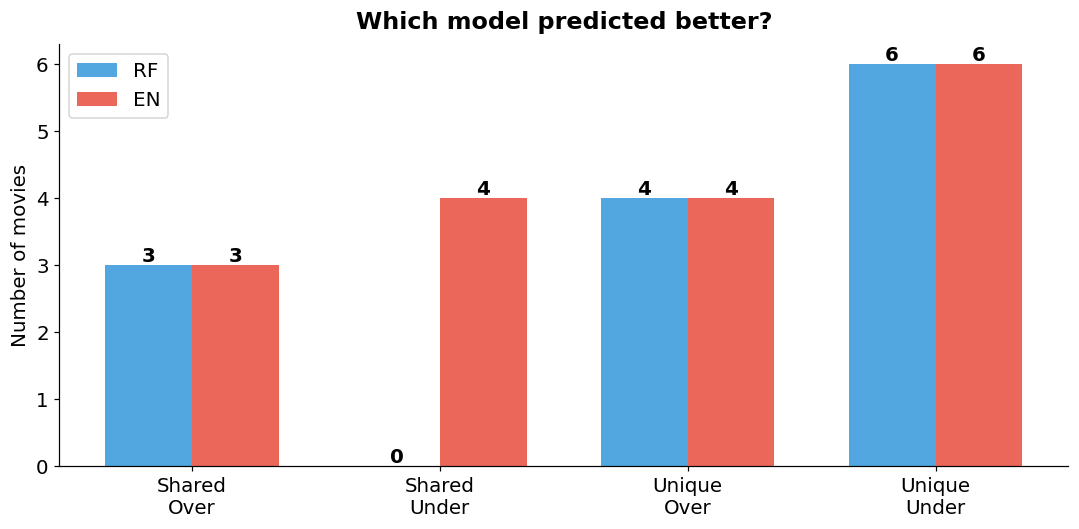

In [60]:
# ── 5.3  visual: who predicted better? ───────────────────────────

categories = ['Shared\nOver', 'Shared\nUnder', 'Unique\nOver', 'Unique\nUnder']
rf_counts  = [(df['better_model']=='RF').sum() for df in [shared_over, shared_under, unique_over, unique_under]]
en_counts  = [(df['better_model']=='EN').sum() for df in [shared_over, shared_under, unique_over, unique_under]]

x = np.arange(len(categories))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, rf_counts, w, label='RF',  color=BLUE, alpha=0.85)
ax.bar(x + w/2, en_counts, w, label='EN',  color=RED,  alpha=0.85)

for i, (r, e) in enumerate(zip(rf_counts, en_counts)):
    ax.text(i - w/2, r + 0.05, str(r), ha='center', fontweight='bold')
    ax.text(i + w/2, e + 0.05, str(e), ha='center', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel('Number of movies')
ax.set_title('Which model predicted better?', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

- **Shared Overpredictions:** EN better in 3/6 cases, RF in 3/6
- **Shared Underpredictions:** EN better in all 4 cases
- **Unique Overpredictions:** tied — EN and RF each better in 4/8 cases
- **Unique Underpredictions:** EN better in 6/12 cases, RF in 6/12

Overall, EN tends to produce smaller errors across most error types,
though the differences are marginal.

## Part 6 - Fairness Analysis

In this section, we examine whether the Random Forest model performs equally well across different subgroups of the data.

### Chosen subgroups for analysis:

**Subgroup 1 - By genre:**
The 5 most frequent genres in the dataset. A movie can belong to more than one genre.
We check whether the model is equally accurate across genres — for example, whether it performs better on Drama than on Thriller.

**Subgroup 2 - By release decade:**
All decades with at least 100 movies (at least 3 decades).
We check whether the model is more accurate on recent movies than on older ones — older movies tend to have more missing information (plot, budget, language).

In [61]:
# ── 6.1  build fairness dataframe ────────────────────────────────
fairness_df = pd.DataFrame({
    'y_true':    y.values,
    'y_pred_rf': y_pred_rf,
}, index=X.index)

# genres from raw data — dropped in prepare_data
fairness_df['genres'] = df_raw.loc[X.index, 'genres']
fairness_df['decade'] = X['decade'].values

print(f'Shape: {fairness_df.shape}')
display(fairness_df.sample(5, random_state=42))

Shape: (115560, 4)


,y_true,y_pred_rf,genres,decade
74304,5.1,4.653883,['Thriller'],2020.0
17129,3.5,6.208549,"Comedy,Romance",2000.0
66669,7.2,6.349824,['Drama'],2010.0
770,7.7,6.759277,Documentary,1960.0
74318,7.8,6.753133,"['Adventure', 'Animation', 'Comedy']",2000.0


### Fairness by Genre

We evaluate model performance separately for the 5 most frequent genres in the dataset.
Note that a single movie can belong to more than one genre, so the subgroups overlap.
All 5 genres are included in the 15 genres the model was trained on, ensuring the model has sufficient exposure to each category.

In [62]:
# ── 6.2  normalize genres ─────────────────────────────────────────
genre_counts = (
    fairness_df['genres']
    .dropna()
    .apply(lambda x: re.sub(r"[\[\]'\"]", '', str(x)))
    .str.split(',')
    .explode()
    .str.strip()
    .str.title()
    .value_counts()
)

print("Top 5 most frequent genres:")
display(genre_counts.head(5).to_frame('count'))

Top 5 most frequent genres:


,count
genres,
Drama,58460
Comedy,33316
Romance,15693
Action,13987
Documentary,13014


In [63]:
# ── 6.3  fairness by genre ────────────────────────────────────────
def calc_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return round(rmse, 4), round(mae, 4)

TOP_5_GENRES = ['Drama', 'Comedy', 'Romance', 'Action', 'Documentary']

genre_results = []
for genre in TOP_5_GENRES:
    mask   = fairness_df['genres'].str.contains(genre, na=False)
    subset = fairness_df[mask]
    rmse, mae = calc_metrics(subset['y_true'], subset['y_pred_rf'])
    genre_results.append({'genre': genre, 'n': len(subset),
                          'RMSE': rmse, 'MAE': mae})

genre_df = pd.DataFrame(genre_results).set_index('genre')
print('Fairness by Genre (Random Forest):')
display(genre_df)

Fairness by Genre (Random Forest):


,n,RMSE,MAE
genre,,,
Drama,58460,1.0544,0.8007
Comedy,33316,1.1236,0.8587
Romance,15693,1.0177,0.7720
Action,13987,1.2142,0.9408
Documentary,13014,1.0014,0.7371


### Fairness by Decade

We evaluate model performance separately for each decade with at least 100 movies.
This threshold ensures that the reported metrics are statistically reliable and not driven by a handful of edge cases.
We expect older decades to show higher error rates due to more missing information (plot, budget, language).

In [64]:
# ── 6.4  fairness by decade ───────────────────────────────────────
decade_counts = fairness_df['decade'].value_counts()
valid_decades = decade_counts[decade_counts >= 100].index.sort_values()

decade_results = []
for decade in valid_decades:
    subset = fairness_df[fairness_df['decade'] == decade]
    rmse, mae = calc_metrics(subset['y_true'], subset['y_pred_rf'])
    decade_results.append({'decade': int(decade), 'n': len(subset),
                           'RMSE': rmse, 'MAE': mae})

decade_df = pd.DataFrame(decade_results).set_index('decade')
print('Fairness by Decade (Random Forest):')
display(decade_df)

Fairness by Decade (Random Forest):


,n,RMSE,MAE
decade,,,
1910,171,0.8403,0.6403
1920,785,0.9855,0.7334
1930,3121,0.8070,0.5992
1940,3292,0.7882,0.5919
1950,4602,0.8565,0.6544
1960,6208,0.9825,0.7701
1970,7969,1.0158,0.7975
1980,9631,1.0539,0.8265
1990,10213,1.0711,0.8295


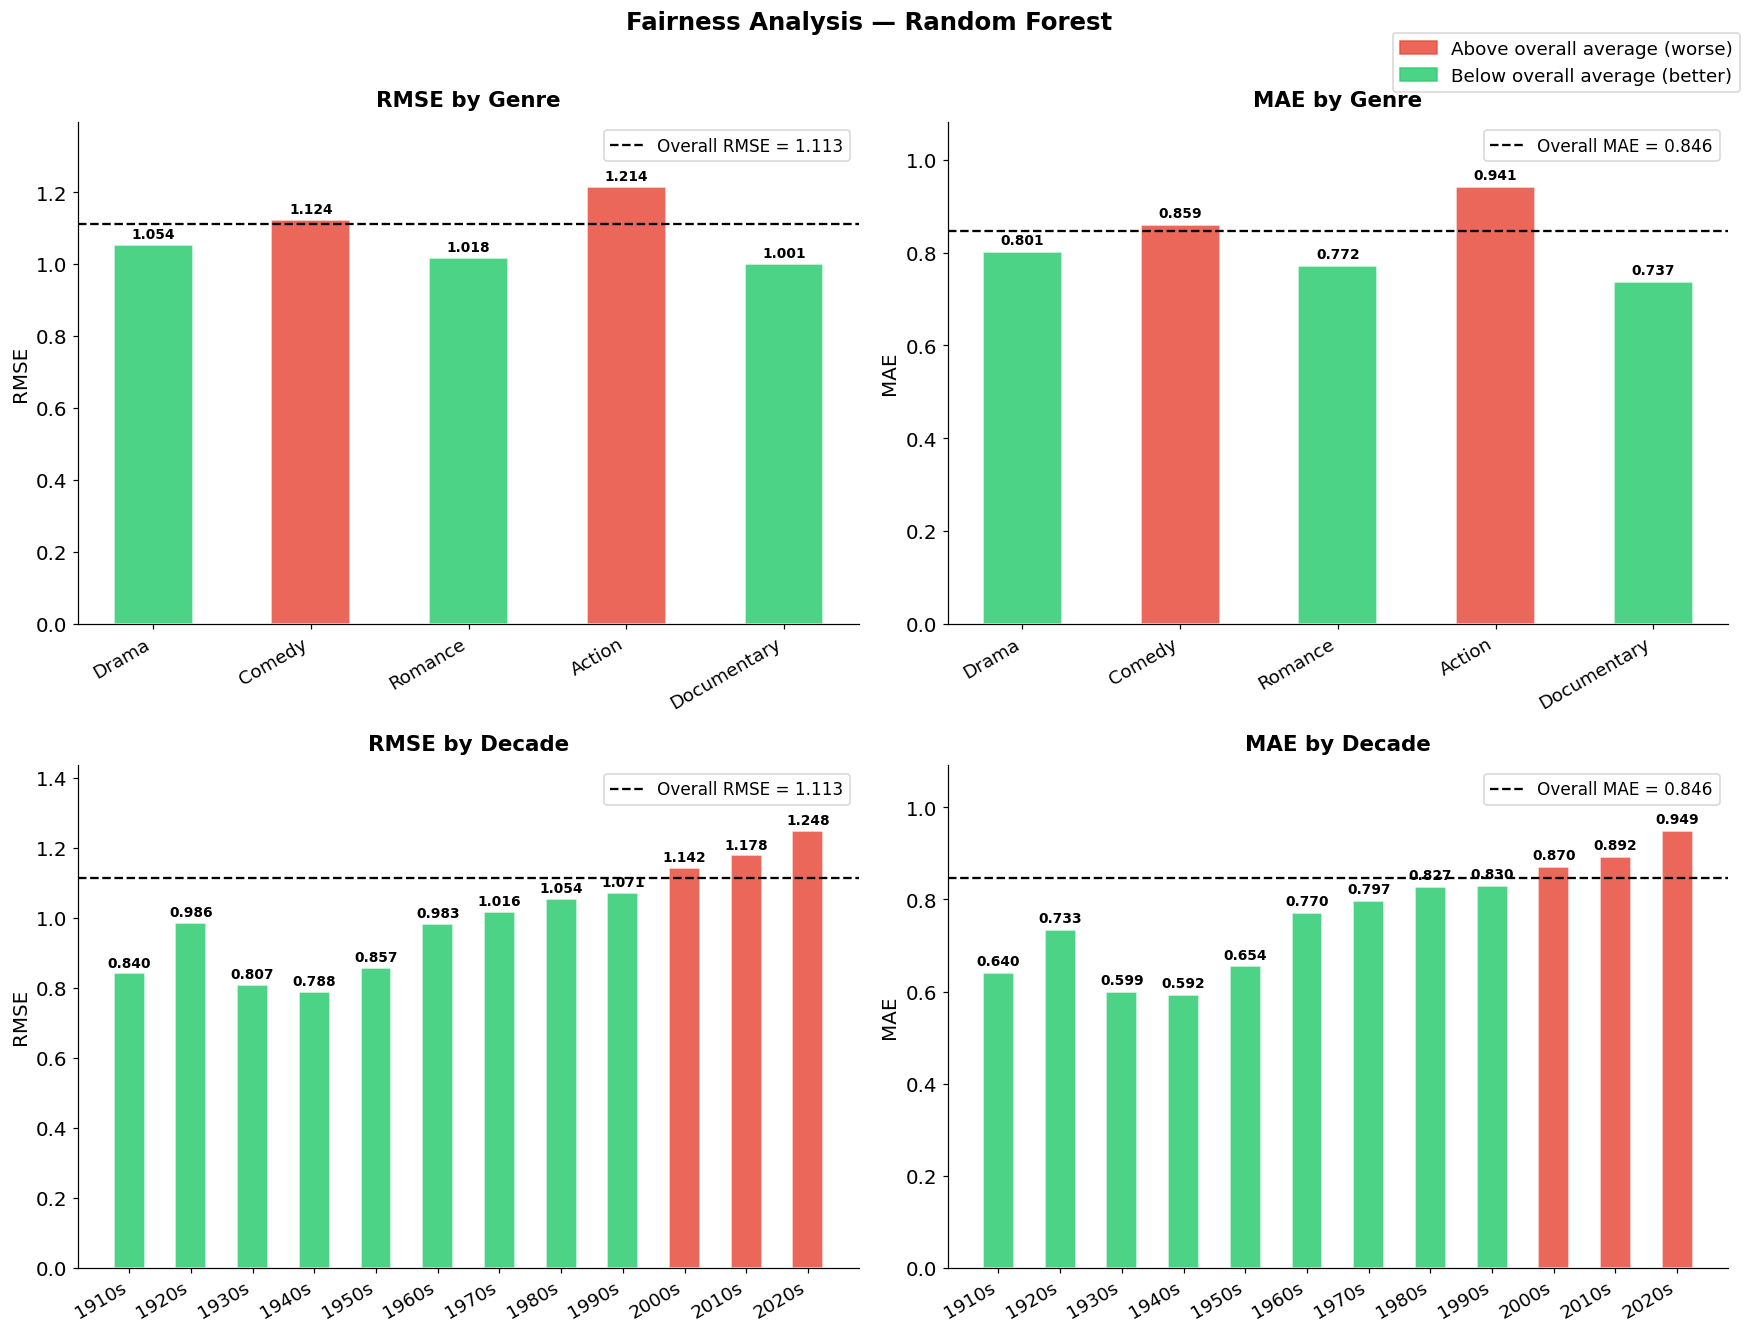

In [65]:
def plot_fairness(ax, values, labels, overall, title, ylabel, fontsize_labels=12):
    colors = [RED if v > overall else GREEN for v in values]
    x = np.arange(len(values))
    bars = ax.bar(x, values, color=colors, alpha=0.85, edgecolor='white', width=0.5)
    ax.axhline(overall, color='black', linestyle='--', linewidth=1.5,
               label=f'Overall {ylabel} = {overall:.3f}')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=fontsize_labels)
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(values) * 1.15)
    ax.legend(fontsize=11)

# ── 6.5  fairness plots ───────────────────────────────────────────
overall_rmse, overall_mae = calc_metrics(fairness_df['y_true'], fairness_df['y_pred_rf'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_fairness(axes[0,0], genre_df['RMSE'],  genre_df.index,  overall_rmse, 'RMSE by Genre',  'RMSE')
plot_fairness(axes[0,1], genre_df['MAE'],   genre_df.index,  overall_mae,  'MAE by Genre',   'MAE')
plot_fairness(axes[1,0], decade_df['RMSE'], [str(d)+'s' for d in decade_df.index], overall_rmse, 'RMSE by Decade', 'RMSE')
plot_fairness(axes[1,1], decade_df['MAE'],  [str(d)+'s' for d in decade_df.index], overall_mae,  'MAE by Decade',  'MAE')

red_patch   = mpatches.Patch(color=RED,   alpha=0.85, label='Above overall average (worse)')
green_patch = mpatches.Patch(color=GREEN, alpha=0.85, label='Below overall average (better)')
fig.legend(handles=[red_patch, green_patch], loc='upper right', fontsize=12,
           frameon=True, bbox_to_anchor=(1.0, 1.0))

plt.suptitle('Fairness Analysis — Random Forest', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Results

**By Genre:** Action shows the highest error (RMSE = 1.214, MAE = 0.9408),
performing 9% above the overall average. Comedy also exceeds the average
(RMSE = 1.123). Documentary and Romance perform best, both below the overall
average (RMSE = 1.0014 and 1.0177 respectively).

**By Decade:** A clear upward trend in error from older to newer decades.
Movies from the 1930s–1980s perform consistently below the overall average.
Error exceeds the average starting from the 2000s, peaking in the 2020s
(RMSE = 1.2477, MAE = 0.949) - 12% above the overall average.
This likely reflects two compounding factors: recent films tend to have more
missing data (plot, budget, language), and their ratings are based on fewer
votes - meaning the average rating has not yet stabilized and may shift
significantly as more viewers rate the film over time.

## Part 7 - Feature Importance Analysis

In this section we identify the five most important features for each model and examine
the direction of their effect on the predicted rating.

For ElasticNet, importance is measured by the standardized coefficients - a positive
coefficient means the feature increases the predicted rating, a negative coefficient
means it decreases it.

For Random Forest, importance is measured by feature importance (mean decrease in
impurity) — this reflects how much each feature contributes to reducing prediction
error across all trees, but does not indicate direction.

We then compare the two models: where do they agree, and where do they diverge?

In [66]:
# ── 7.1  feature names ────────────────────────────────────────────
feature_names = (
    numerical_vars +
    list(gs_en.best_estimator_['preprocessor']
         .named_transformers_['cat']['OHE']
         .get_feature_names_out(categorical_vars)) +
    binary_vars
)

coef    = gs_en.best_estimator_['model'].coef_
importances = gs_rf.best_estimator_['model'].feature_importances_

In [67]:
# ── 7.2  feature importance plots ────────────────────────────────

def plot_importance(ax, features, values, title):
    colors = [GREEN if v > 0 else RED for v in values]
    ax.vlines(range(len(features)), 0, values,
              colors=colors, linewidth=2.5, alpha=0.6)
    ax.scatter(range(len(features)), values,
               color=colors, edgecolors='white', s=140, zorder=3)
    ax.axhline(0, color='#334155', linewidth=1.5)
    space = max(abs(values)) * 0.05
    for i, val in enumerate(values):
        sign = '+' if val >= 0 else ''
        va   = 'bottom' if val >= 0 else 'top'
        ax.text(i, val + space if val >= 0 else val - space,
                f'{sign}{val:.4f}', ha='center', va=va,
                fontsize=9.5, fontweight='bold', color='#1e293b')
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels(features, fontweight='bold', fontsize=10)
    ax.set_ylim(-max(abs(values)) * 1.3, max(abs(values)) * 1.3)
    ax.set_xlim(-0.6, len(features) - 0.4)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=22, loc='left')
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

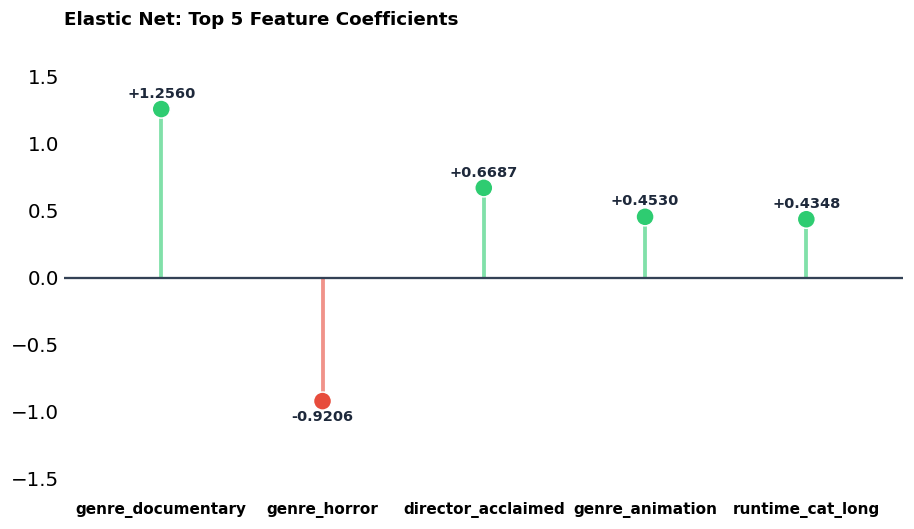

In [68]:
# ── 7.2  ElasticNet: top 5 coefficients plot ─────────────────────
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coef})
top5_en = coef_df.reindex(coef_df['coefficient'].abs().nlargest(5).index)

fig, ax = plt.subplots(figsize=(8.5, 5))
plot_importance(ax, top5_en['feature'].tolist(),
                top5_en['coefficient'].values,
                'Elastic Net: Top 5 Feature Coefficients')
plt.tight_layout()
plt.show()

In [70]:
# ── 7.3 Random Forest: top 5 feature importance ───────────
imp_df  = pd.DataFrame({'feature': feature_names, 'importance': importances})
top5_rf = imp_df.nlargest(5, 'importance')

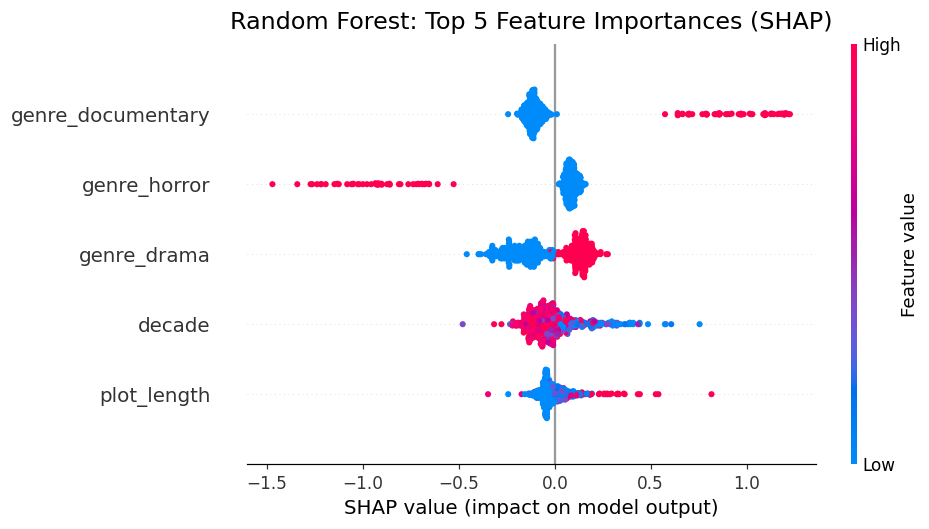

In [72]:
# ── 7.4  Random Forest: SHAP direction and magnitude ───────────
X_transformed = gs_rf.best_estimator_['preprocessor'].transform(X)
sample_idx    = np.random.RandomState(42).choice(
                    X_transformed.shape[0], size=500, replace=False)
X_sample      = X_transformed[sample_idx]

explainer   = shap.TreeExplainer(
                  gs_rf.best_estimator_['model'],
                  feature_perturbation='tree_path_dependent'
              )
shap_values = explainer.shap_values(X_sample)

top5_idx = [feature_names.index(f) for f in top5_rf['feature']]

shap.summary_plot(
    shap_values[:, top5_idx],
    X_sample[:, top5_idx],
    feature_names=top5_rf['feature'].tolist(),
    plot_size=(9, 5),
    show=False
)
plt.title('Random Forest: Top 5 Feature Importances (SHAP)')
plt.tight_layout()
plt.show()

### Feature Importance Analysis

**Agreement between models:**
Both models identify `genre_documentary` as the most important feature
with a positive effect, and `genre_horror` as having a strong negative
effect on predicted rating.

**Where they diverge:**

- **`plot_length`** ranks second in RF but does not appear in EN's top 5 -
RF relies heavily on plot text availability, EN ignores it.

- **`director_acclaimed`** is among the top features in EN with a positive
effect, but absent from RF - EN explicitly rewards films with recognized
directors, while RF does not isolate this signal.

- **`decade`** appears in RF with a complex, non-linear effect -
SHAP values spread in both directions, suggesting its impact depends
on interactions with other features rather than a simple directional trend.

- **`genre_animation`** and **`runtime_cat_long`** appear only in EN
with positive coefficients, while RF distributes their effect across
many trees without isolating them.

## Part 8 - Held-Out Test Set

The final model is trained on the full dataset (X, y) using the optimal
parameters found in GridSearch. This ensures maximum use of available
data before evaluation on the held-out test set.

The model is serialized using joblib and saved as `model.pkl`.
At test time, the model will be loaded and applied as follows:

```python
df   = pd.read_csv("train.csv")
y    = df["averageRating"]
X    = prepare_data(df)
model = joblib.load("model.pkl")
y_pred = model.predict(X)
```
```

In [73]:
# ── Section 8 train final model on ALL data ─────────────────────
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet(
        alpha        = gs_en.best_params_['model__alpha'],
        l1_ratio     = gs_en.best_params_['model__l1_ratio'],
        max_iter     = 10000,
        random_state = 42
    ))
])

final_model.fit(X, y)

import joblib
joblib.dump(final_model, 'model.pkl')
print(f"✅ Final model saved")
print(f"   Best params: {gs_en.best_params_}")
print(f"   Training samples: {len(X):,}")

✅ Final model saved
   Best params: {'model__alpha': 0.0001, 'model__l1_ratio': 0.1}
   Training samples: 115,560
